<a href="https://colab.research.google.com/github/Loopinlogix/Stock_Market_Analysis/blob/main/Stock_Market_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stock Market Analysis - Project 1

In [1]:
#Github

#Github
!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"

!git clone https://https://github.com/Loopinlogix/Stock_Market_Analysis.git
%cd Stock_Market_Analysis
!ls


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Cloning into 'Stock_Market_Analysis'...
fatal: unable to access 'https://https://github.com/Loopinlogix/Stock_Market_Analysis.git/': Could not resolve host: https
[Errno 2] No such file or directory: 'Stock_Market_Analysis'
/content
sample_data


STEP 1: DATA COLLECTION
  ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013-05-14
  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PR

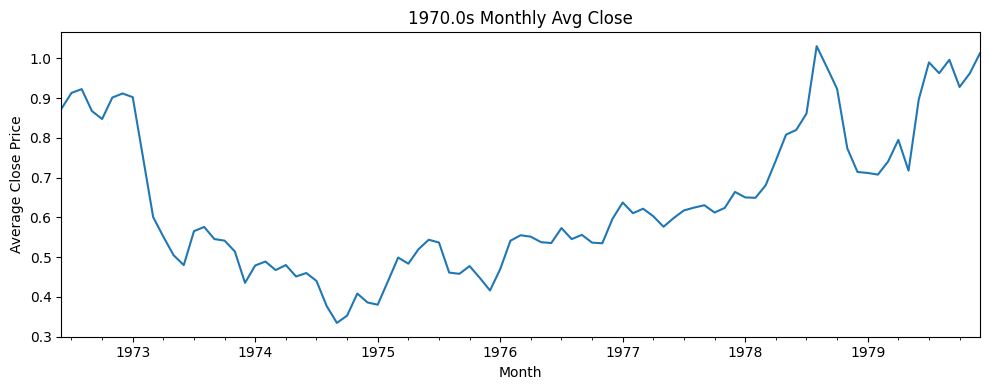

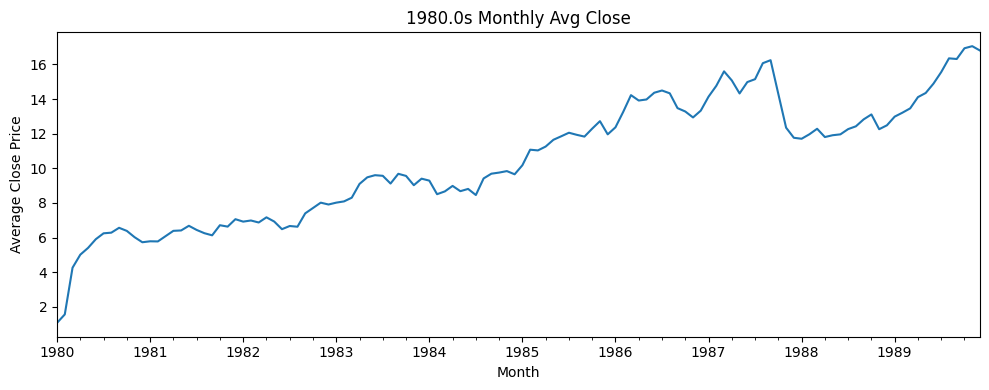

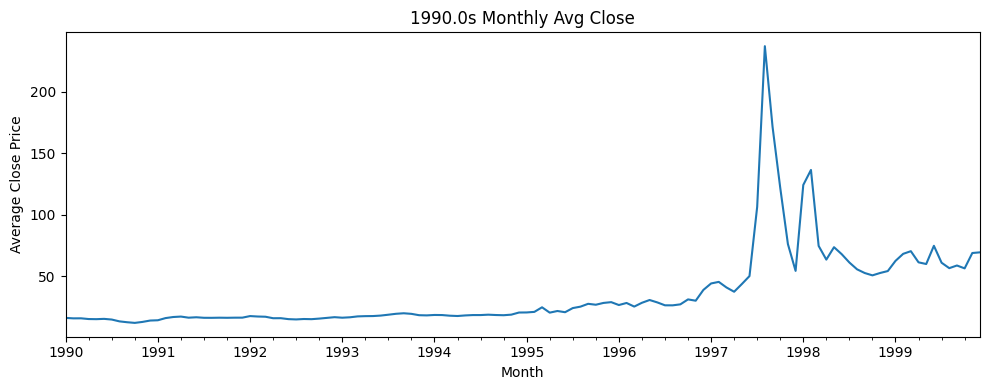

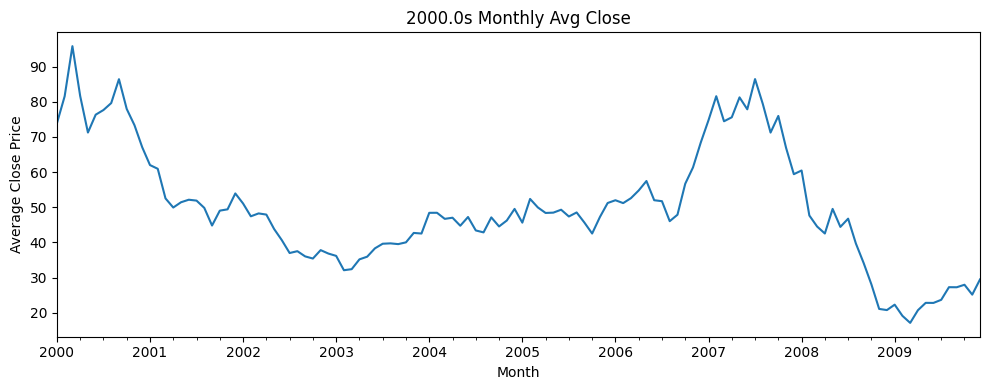

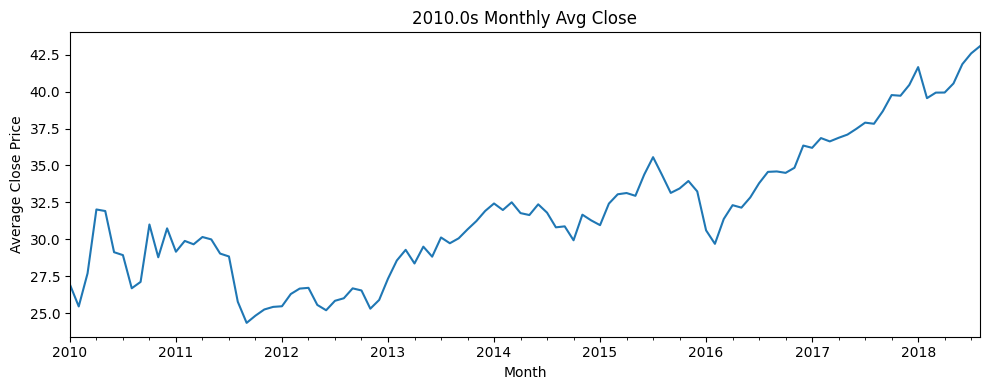

STEP 7: HISTOGRAM


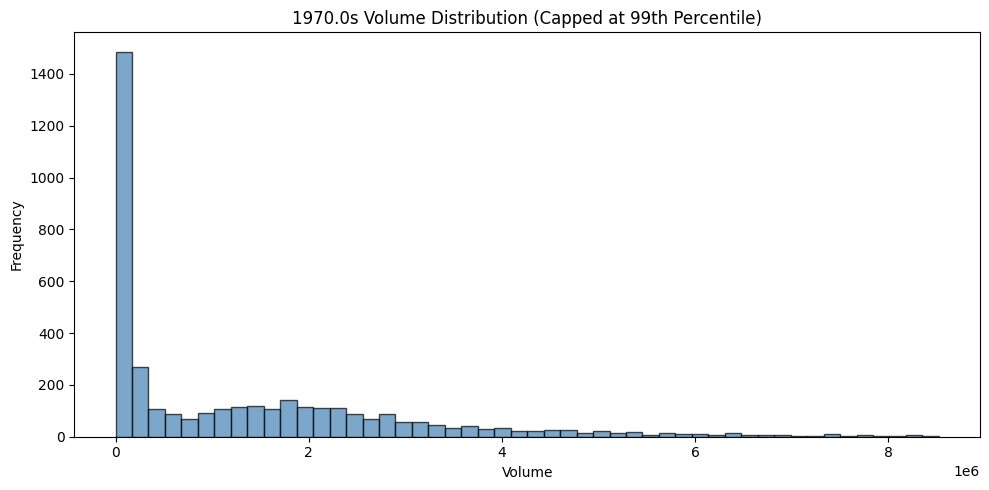

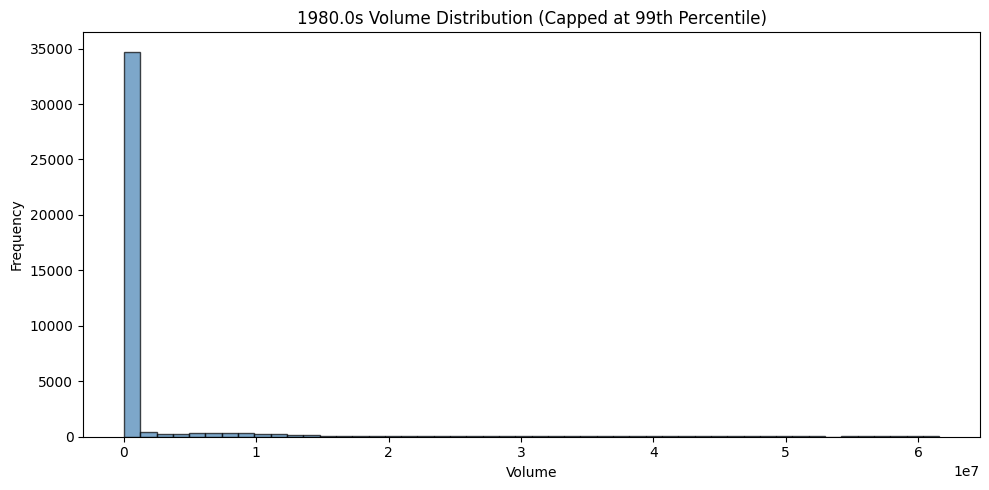

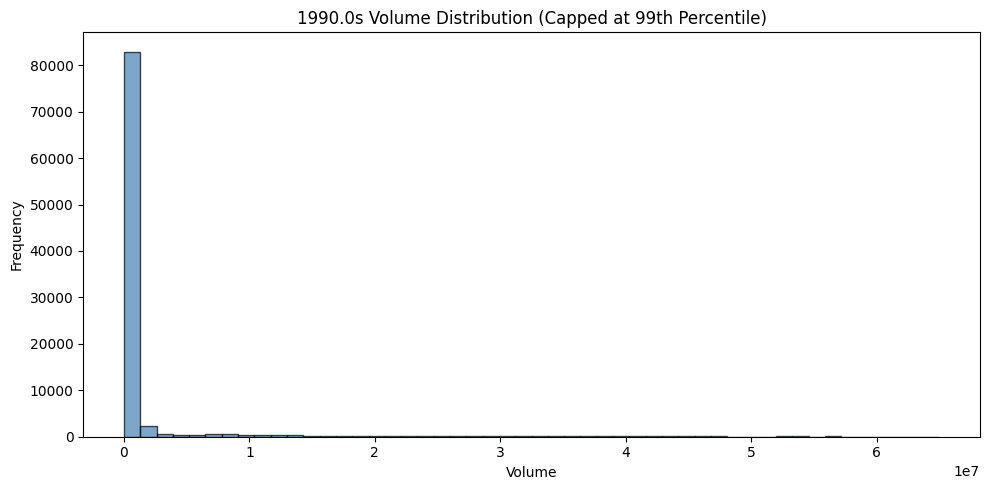

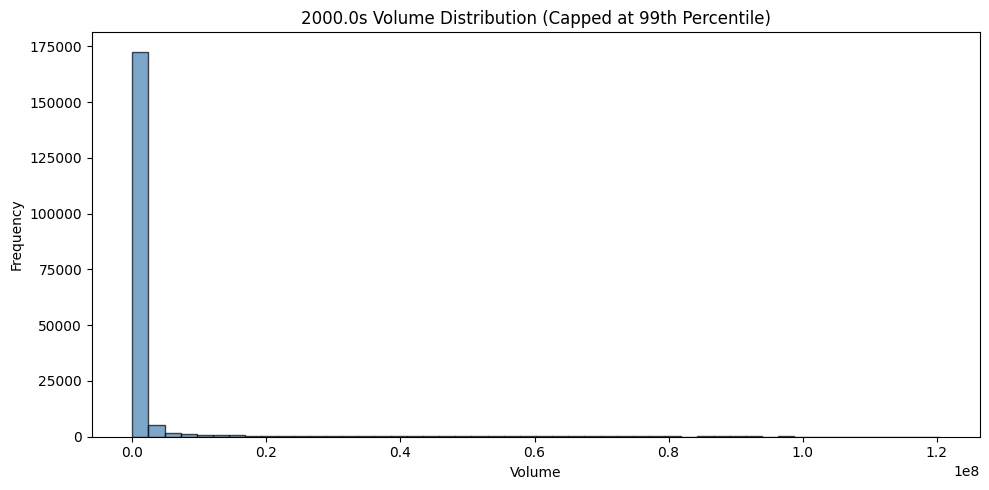

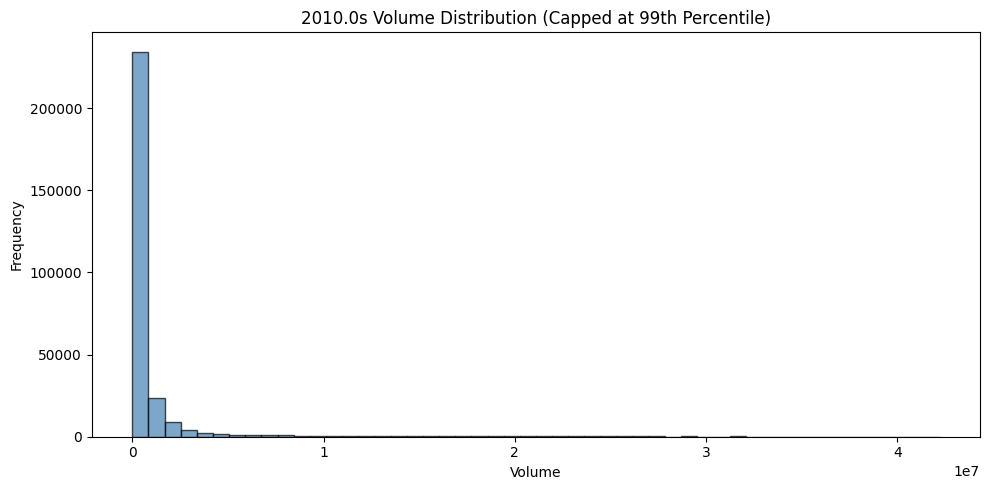

STEP 7: BOXPLOT


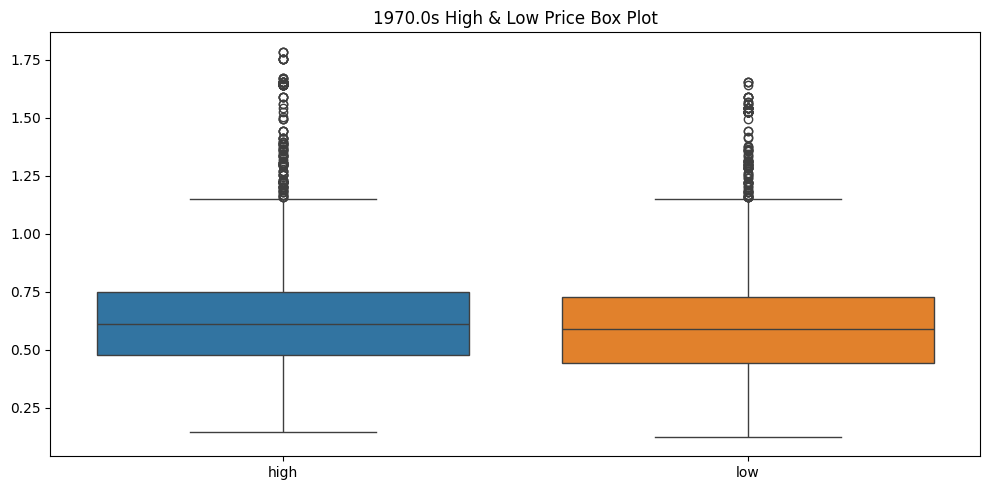

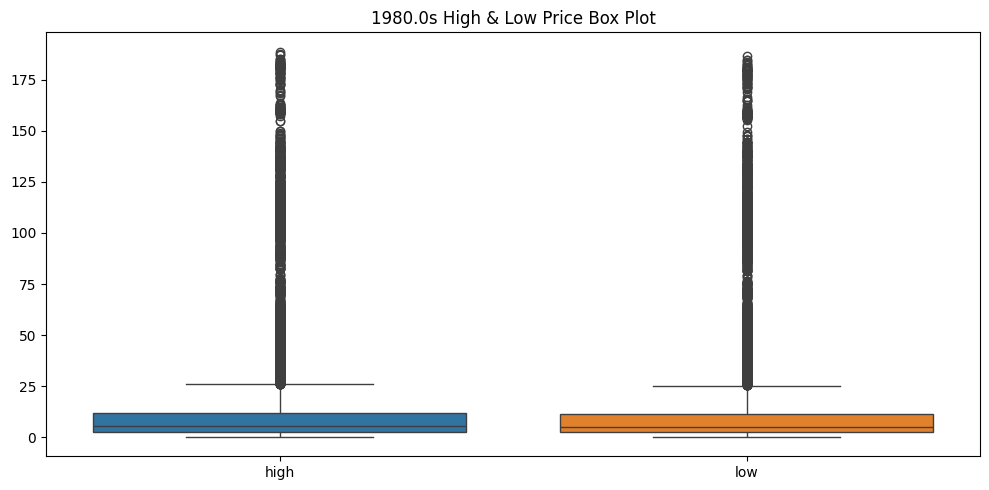

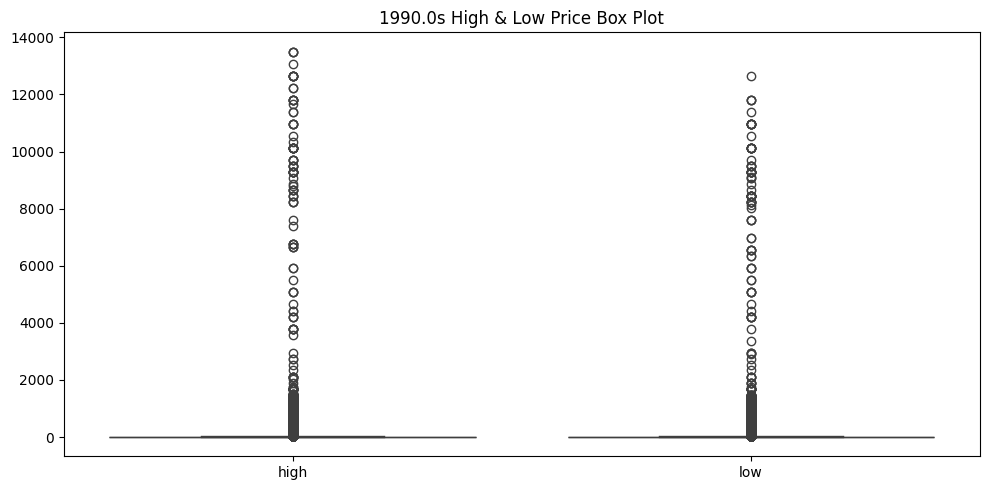

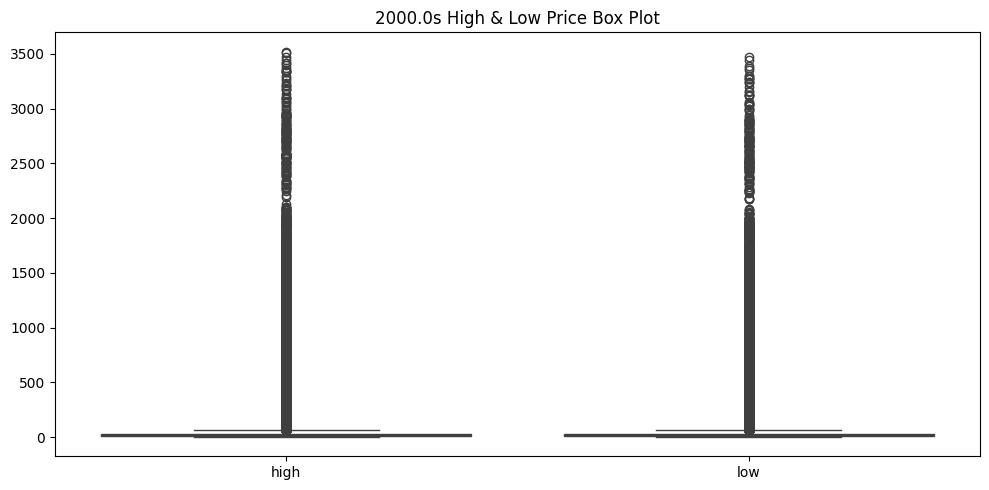

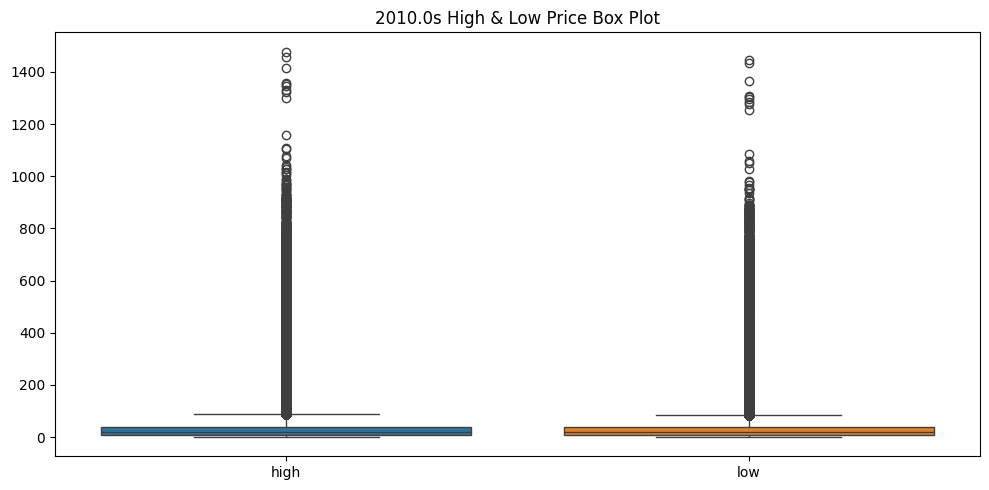

STEP 8: MULTI-DECADE COMPARISON PLOTS


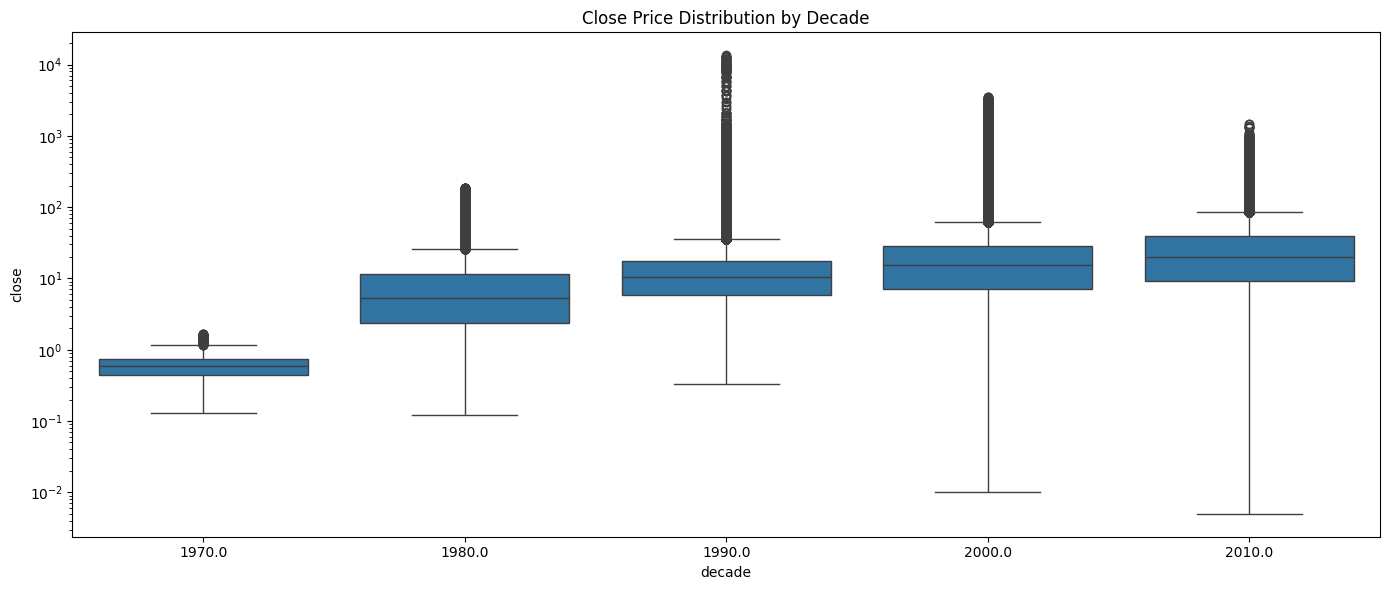

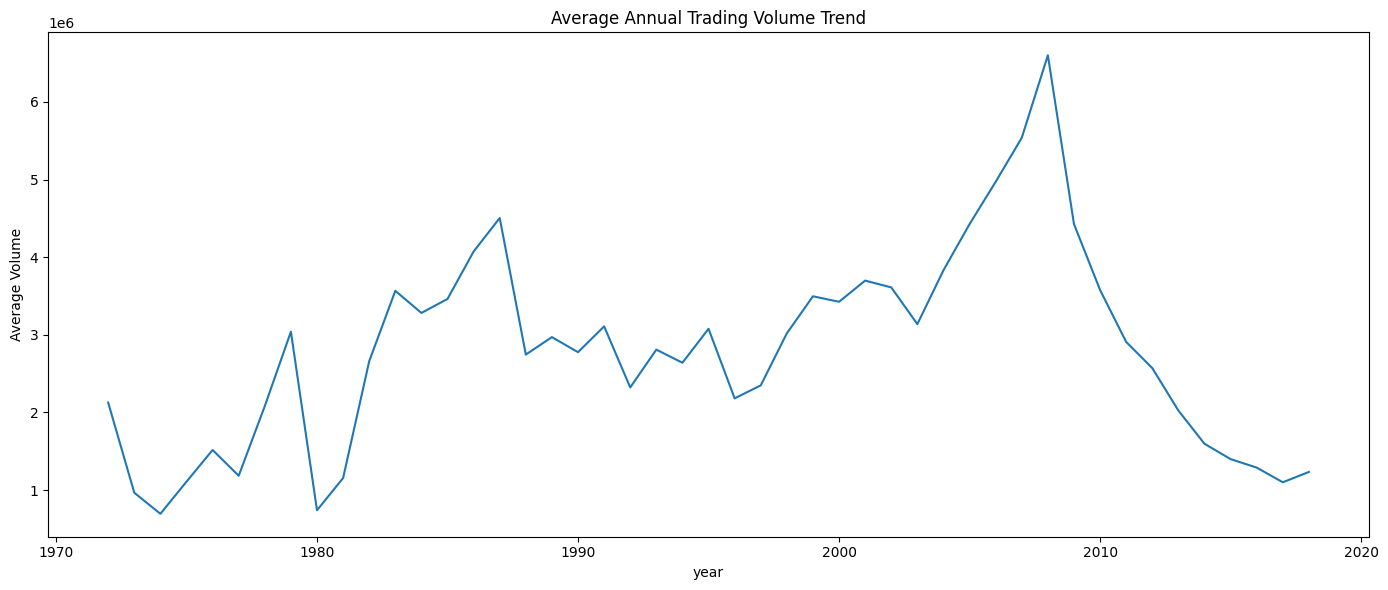

STEP 10: HEATMAP - OVERALL CORRELATION MATRIX

Raw correlation matrix:
            open      high       low     close    volume
open    1.000000  0.998261  0.995781  0.999812 -0.009177
high    0.998261  1.000000  0.994619  0.998292 -0.009161
low     0.995781  0.994619  1.000000  0.995778 -0.009284
close   0.999812  0.998292  0.995778  1.000000 -0.009186
volume -0.009177 -0.009161 -0.009284 -0.009186  1.000000


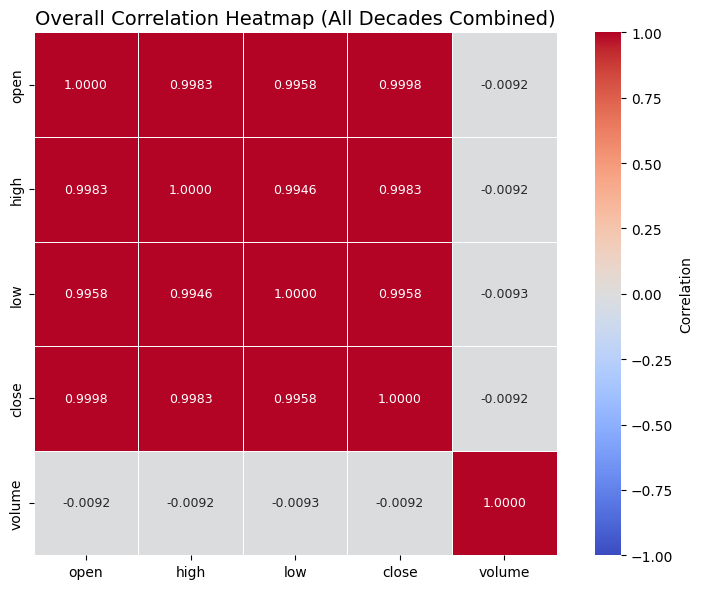

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 60)
print("STEP 1: DATA COLLECTION")
print("=" * 60)

stocks = pd.read_csv('historical_stocks.csv')
prices = pd.read_csv('historical_stock_prices.csv')

# STANDARDIZE COLUMN NAMES TO LOWERCASE
prices.columns = prices.columns.str.strip().str.lower()
stocks.columns = stocks.columns.str.strip().str.lower()

print(prices.head())
print(stocks.head())
print(prices.info())

print("=" * 60)
print("STEP 2: DATA CLEANING")
print("=" * 60)

print("Missing values:\n", prices.isnull().sum())

prices = prices.fillna(prices.median(numeric_only=True))
prices = prices.drop_duplicates()


print("\n--- DIAGNOSTICS ---")
print("Unique values per column:")
print(prices[['open', 'high', 'low', 'close', 'volume']].nunique())
print("\nStandard deviation:")
print(prices[['open', 'high', 'low', 'close', 'volume']].std())
print("\nFirst 5 rows:")
print(prices[['open', 'high', 'low', 'close', 'volume']].head())

# Convert Date Column
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.set_index('date')

print("=" * 60)
print("STEP 3: DATA SEGMENTATION BY DECADE")
print("=" * 60)

prices['year'] = prices.index.year
prices['decade'] = (prices['year'] // 10) * 10

decades = dict(tuple(prices.groupby('decade')))
for decade, df in decades.items():
    print(f"Decade {decade}: {len(df)} rows")

print("=" * 60)
print("STEP 4: MERGE DATASETS")
print("=" * 60)

print("Prices columns:", prices.columns.tolist())
print("Stocks columns:", stocks.columns.tolist())

# Merge on 'ticker' (both standardized to lowercase)
merged = pd.merge(prices.reset_index(), stocks, on='ticker')
print(merged.head())

print("=" * 60)
print("STEP 5: SUMMARY STATISTICS")
print("=" * 60)

for decade, df in decades.items():
    print(f"\nDecade: {decade}")
    print(df[['open', 'high', 'low', 'close', 'volume']].describe())

print("=" * 60)
print("STEP 6: VISUALIZATION")
print("=" * 60)

for decade, df in decades.items():
    monthly = df['close'].resample('ME').mean()
    monthly.plot(title=f"{decade}s Monthly Avg Close", figsize=(10, 4))
    plt.ylabel('Average Close Price')
    plt.xlabel('Month')
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("STEP 7: HISTOGRAM")
print("=" * 60)

for decade, df in decades.items():
    plt.figure(figsize=(10, 5))

    # Option 1: Cap extreme outliers (e.g., 99th percentile)
    cap = df['volume'].quantile(0.99)
    filtered = df[df['volume'] <= cap]['volume']

    plt.hist(filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.title(f"{decade}s Volume Distribution (Capped at 99th Percentile)")
    plt.xlabel('Volume')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("STEP 7: BOXPLOT")
print("=" * 60)


for decade, df in decades.items():
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df[['high', 'low']])
    plt.title(f"{decade}s High & Low Price Box Plot")
    plt.tight_layout()
    plt.show()


print("=" * 60)
print("STEP 8: MULTI-DECADE COMPARISON PLOTS")
print("=" * 60)

# Side-by-side boxplot of Close prices by decade
plt.figure(figsize=(14, 6))
prices_reset = prices.reset_index()
sns.boxplot(data=prices_reset, x='decade', y='close')
plt.title('Close Price Distribution by Decade')
plt.yscale('log')  # Log scale due to inflation
plt.tight_layout()
plt.show()

# Volume trend over time
plt.figure(figsize=(14, 6))
yearly_volume = prices.groupby('year')['volume'].mean()
yearly_volume.plot()
plt.title('Average Annual Trading Volume Trend')
plt.ylabel('Average Volume')
plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 60)
print("STEP 10: HEATMAP - OVERALL CORRELATION MATRIX")
print("=" * 60)

price_cols = ['open', 'high', 'low', 'close', 'volume']
all_data = pd.concat(decades.values())
corr_matrix = all_data[price_cols].corr()

# Print raw values first to verify
print("\nRaw correlation matrix:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.4f',        # ← Changed from .2f to .4f
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9},  # Smaller font for more digits
    cbar_kws={'label': 'Correlation'}
)
plt.title("Overall Correlation Heatmap (All Decades Combined)", fontsize=14)
plt.tight_layout()
plt.show()
